# Регрессия для CC50

Необходимо сравнить различные модели с настройкой гиперпараметров для предсказания значения цитотоксической концентрации соединений (CC50) на основе их молекулярных дескрипторов. CC50 является количественной целевой переменной, характеризующей токсичность потенциальных лекарственных соединений.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

import xgboost as xgb
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных

In [ ]:
df = pd.read_csv('/data/clean_data.csv')
print('Размерность датасета:', df.shape)
df.head()

Размерность датасета: (969, 213)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.describe()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,...,969.000000,969.000000,969.000000,969.000000,969.000000,969.000000,969.0,969.000000,969.000000,969.000000
mean,220.726223,586.419908,73.967907,10.893712,10.893712,0.179533,-0.960140,0.577633,29.370350,351.486139,...,0.055728,0.012384,0.009288,0.001032,0.001032,0.053664,0.0,0.070175,0.208462,0.007224
std,397.172441,633.624464,695.564665,3.284005,3.284005,0.168928,1.567568,0.213316,12.605779,127.388186,...,0.263069,0.110649,0.095975,0.032125,0.032125,0.225469,0.0,0.255574,1.231428,0.084730
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999345,1.488095,10.006389,10.006389,0.050979,-1.333174,0.442842,18.500000,266.252000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,45.338355,424.166213,3.900000,12.196496,12.196496,0.123850,-0.419485,0.634372,29.200000,318.373000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,231.373089,891.776925,16.375000,13.178870,13.178870,0.291020,0.007873,0.742483,38.600000,413.670000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


## Подготовка данных к обучению модели

При моделировании необходимо учитывать, что индекс селективности SI вычисляется на основе значений IC50 и CC50. Следовательно, для задач прогнозирования SI нельзя использовать IC50 и CC50 в качестве признаков. Аналогично, при моделировании IC50 запрещено использовать SI и CC50, а при моделировании CC50 - SI и IC50, чтобы избежать утечки данных и некорректного завышения качества моделей.

Для решения задач регрессии с целевыми переменными, характеризующимися сильной асимметрией распределения, выявленной при анализе данных, применяется логарифмическое преобразование log1p. Расчет метрик качества при этом выполняется в логарифмической шкале, что позволяет корректно оценивать относительные ошибки предсказаний.

Построим графики распределния целевой переменной CC50 и ее логарифма log1p(CC50).

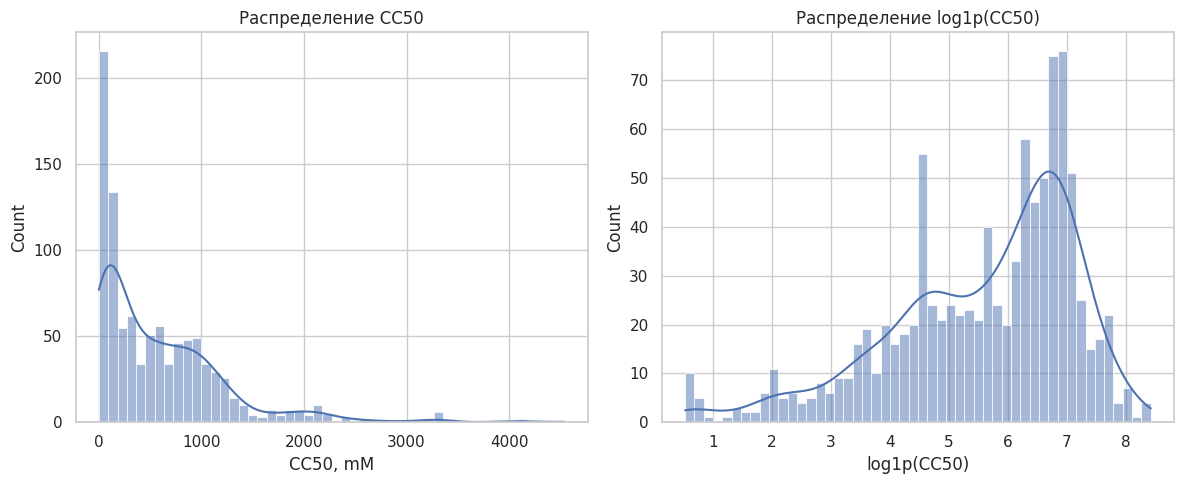

In [ ]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Исходное распределение CC50
sns.histplot(df['CC50, mM'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Распределение CC50')
axes[0].set_xlabel('CC50, mM')

# Логарифмическое распределение CC50
sns.histplot(np.log1p(df['CC50, mM']), kde=True, bins=50, ax=axes[1])
axes[1].set_title('Распределение log1p(CC50)')
axes[1].set_xlabel('log1p(CC50)')

plt.tight_layout()
plt.show()

In [ ]:
# Удаляем утечки, так как SI = CC50/IC50
df = df.drop(columns=['SI', 'IC50, mM'])

# Признаки / таргет
X = df.drop(columns=['CC50, mM'])
y =  np.log1p(df['CC50, mM'])

Так как ранее на этапе EDA в общей даграмме присутствовало много признаком, которые сильно коррелируют между собой, напишем функцию для устранения мультиколлинеарности путем удаления этих сильно коррелирующих между собой переменных.

In [ ]:
def drop_high_corr(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X, dropped_cols = drop_high_corr(X, threshold=0.8)

print(f"Удалено {len(dropped_cols)} признаков")

Удалено 72 признаков


Данная функция вычисляет матрицу абсолютных коэффициентов корреляции Пирсона для всех признаков, выделяет верхнюю треугольную часть матрицы, исключая главную диагональ и идентифицирует пары признаков, коэффициент корреляции между которыми превышает заданный порог. Для каждой такой пары функция помечает один из признаков для удаления, оставляя в датасете только некоррелирующие между собой переменные.

Это важно для многих моделей машинного обучения, особенно линейных, где высокая корреляция между признаками приводит к нестабильности оценок коэффициентов, снижению интерпретируемости и переобучению.

Дополнительно проводить количественную оценку мультиколлинеарности в наборе признаков с использованием фактора инфляции дисперсии, как в классификации IC50 не будем, так как после тестирования модели, выявил, что некоторые признаки, которые важны для улучшения обобщающей способности модели, удаляются после применения данного метода.

Таким образом, с использованием одного метода мы избавились от мультиколлинеарности.


Разделим данные на тренировочную и тестовую выбоки:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 775 строк
Тестовая выборка: 194 строк


## Обучение моделей

Для данной задачи будем рассматривать 6 различных моделей: гребневая регрессия, регрессия Лассо, случайный лес, градиентный бустинг, XGBoost и LightGBM.

Для каждой модели проводится подбор гиперпараметров с помощью GridSearchCV и 5-кратной кросс-валидации, в качестве метрики оптимизации выбрана среднеквадратичная ошибка (MSE).

Оценивать качество моделей будем по трем метрикам:
- средняя абсолютная ошибка - MAE
- корень из среднеквадратичной ошибки - RMSE
- коэффициент детерминации - R^2

In [ ]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "MAE_train": mean_absolute_error(y_train, pred_train),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2_test": r2_score(y_test, pred_test)
    }

Выше представлена общая функция для предсказания и оценки модели. Она обучает модель на тренировочных данных, делает предсказания на обеих выборках и возвращает ключевые метрики: MAE (на обучении и тесте), RMSE и R^2 на тестовых данных.

Перейдем к обучению моделей:

**Гребневая регрессия**

In [ ]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

params_ridge = {
    'model__alpha': [0.1, 1, 10, 50, 100, 150, 200]
}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)

res_ridge = evaluate(grid_ridge.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_ridge.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_ridge.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 200}
Наилучшая метрика MSE: 2.3056


**Регрессия Лассо**

In [ ]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000))
])

params_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 15]
}

grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

res_lasso = evaluate(grid_lasso.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lasso.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lasso.best_score_:.4f}")

Лучшие параметры: {'model__alpha': 0.1}
Наилучшая метрика MSE: 1.9459


**Случайный лес**

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

params_rf = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 0.5, 0.7],
    'bootstrap': [True, False],
}

grid_rf = GridSearchCV(rf, params_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

res_rf = evaluate(grid_rf.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_rf.best_score_:.4f}")

Лучшие параметры: {'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Наилучшая метрика MSE: 1.4475


**Градиентный бустинг**

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

params_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.85, 1.0],
}

grid_gb = GridSearchCV(gb, params_gb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

res_gb = evaluate(grid_gb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_gb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_gb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.02, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Наилучшая метрика MSE: 1.4866


**XGBRegressor**

In [ ]:
xgbr = xgb.XGBRegressor(random_state=42, n_jobs=-1)

params_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.02, 0.05, 0.1]
}

grid_xgb = GridSearchCV(xgbr, params_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

res_xgb = evaluate(grid_xgb.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_xgb.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Наилучшая метрика MSE: 1.5325


**LightGBM**

In [ ]:
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

params_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
}

grid_lgbm = GridSearchCV(lgbm, params_lgbm, cv=5, scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=1)
grid_lgbm.fit(X_train, y_train)

res_lgbm = evaluate(grid_lgbm.best_estimator_, X_train, X_test, y_train, y_test)

print(f"Лучшие параметры: {grid_lgbm.best_params_}")
print(f"Наилучшая метрика MSE: {-grid_lgbm.best_score_:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9070
[LightGBM] [Info] Number of data points in the train set: 775, number of used features: 97
[LightGBM] [Info] Start training from score 5.571405
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

Соберем датафрейм с результатами моделей:

In [ ]:
results = pd.DataFrame({
    'Ridge': res_ridge,
    'Lasso': res_lasso,
    'RandomForest': res_rf,
    'GradientBoosting': res_gb,
    'XGBoost': res_xgb,
    'LGBMRegressor': res_lgbm
}).T

results.sort_values('RMSE_test')

,MAE_train,MAE_test,RMSE_test,R2_test
LGBMRegressor,0.511791,0.866899,1.236444,0.349214
Ridge,0.921574,0.938380,1.249546,0.335349
XGBoost,0.598558,0.909793,1.255976,0.328491
GradientBoosting,0.444545,0.857947,1.265509,0.318259
Lasso,1.060954,1.053567,1.309285,0.270278
RandomForest,0.157056,0.864429,1.316023,0.262748


В результате построения 6 моделей можно сделать следующие выводы:

- Среди шести рассмотренных моделей регрессии лучший результат по основным метрикам показал LGBMRegressor, достигнув наибольшего R^2 = 0.349 и наименьшего RMSE = 1.236 на тестовой выборке. Ridge занял второе место с минимальным разрывом между MAE на обучении и тесте, что свидетельствует о хорошей обобщающей способности. XGBoost и градиентный бустинг продемонстрировали близкие результаты, тогда как Lasso и случайный лес оказались наихудшими.

- Наиболее интересное наблюдение - это то, что случайный лес показывает отличные метрики на обучении, но сильное падение на тесте, что является классическим примером сильнейшего переобучения. С уверенностью можно сказать, что это связано с избыточной глубиной деревьев, и, возможно, недостаточным количеством объектов в выборке. В то время как LGBMRegressor и градиентный бустинг демонстрируют более сбалансированное поведение, а линейные модели - минимальный разрыв между метриками на тренировочной и тестовой выборках, что подтверждает устойчивость линейных моделей к переобучению на небольших данных.

**Рекомендации:**

В качестве финальной модели для предсказания CC50 рекомендуется LGBMRegressor как наилучшая модель по R^2 и RMSE. Для улучшения качества можно провести более глубокую настройку гиперпараметров, например, num_leaves, min_child_samples, learning_rate, а также применить раннюю остановку для борьбы с переобучением. Для случайного леса необходимо ужесточить регуляризацию - уменьшить max_depth, увеличить min_samples_split и min_samples_leaf. Учитывая, что максимальный R^2 не превышает 0.35, целесообразно рассмотреть добавление новых признаков или перейти к использованию более сложных моделей - ансамблей, способным лучше учитывать особенности данных.
